In [188]:
from pathlib import Path

from itertools import product
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats
from torch.ao.nn.quantized.functional import threshold

In [24]:
import scaling

from scaling.utils import get_pareto_frontier, functional_form_L0, fit_parametric_form

---

In [3]:
# here, define the suitable path for relative sourcing for the rest of the notebook

CWD = Path().resolve().parent
CWD

PosixPath('/Users/mallik/Documents/git_repos/EffingScaling')

In [4]:
BASE_PATH = CWD / "data" / "nanotab"
BASE_PATH

PosixPath('/Users/mallik/Documents/git_repos/EffingScaling/data/nanotab')

In [5]:
# data read

PARENT_SEED = 42
SEEDS = [1826, 1926, 2126, 2226]
SEEDS.append(PARENT_SEED)

DATANAMES = (
    # "s1",
    "s1_seed=1826",
    "s1_seed=1926",
    "s1_seed=2126",
    "s1_seed=2226",
    # "s1.1",
    "s1.1_seed=1826",
    "s1.1_seed=1926",
    "s1.1_seed=2126",
    "s1.1_seed=2226",
    # "s1.2",
    "s1.2_seed=1826",
    "s1.2_seed=1926",
    "s1.2_seed=2126",
    "s1.2_seed=2226",
    # "s2",
    # "s2_seed=1826",
    # "s2_seed=1926",
    # "s2_seed=2126",
    # "s2_seed=2226",
)

dfs = []
for dataname in DATANAMES:
    _filename = f"run_summary_{dataname}.pickle.xz"
    df = pd.read_pickle(BASE_PATH / _filename)
    dfs.append(df)

In [6]:
df = pd.concat(dfs, ignore_index=True)
display(df.head())
print(df.shape)
print(df.columns)

,config/effective_batch_size,config/lr,config/max_features,config/mlp_hidden_multiple,config/model_config.embedding_size,config/model_config.num_attention_heads,config/model_config.num_layers,config/model_optimizer,config/num_datapoints_max,config/num_flops_training,...,real_data/inference_time,real_data/memory_usage,real_data/balanced_accuracy,real_data/roc_auc,real_data/nll,real_data/accuracy,val/val_loss,val/medium/val_loss,val/small/val_loss,config/model_config.mlp_hidden_multiple
0,32,0.00347,4,4.0,16,2,2,adamW,100,1.000000e+13,...,step 148 0.335012 261 0.334930 468 ...,step 148 369.515589 261 369.515589 4...,step 148 0.435010 261 0.437612 468 ...,step 148 0.522680 261 0.521500 468 ...,step 148 0.683696 261 0.662698 468 ...,step 148 0.558930 261 0.562815 468 ...,step 148 1.186853 261 1.211007 468 ...,step 148 1.241395 261 1.272892 468 ...,step 148 1.132310 261 1.149121 468 ...,NaN
1,32,0.00347,4,4.0,16,2,2,adamW,400,1.000000e+13,...,step 35 0.338544 63 0.339071 113 ...,step 35 369.515589 63 369.515589 113...,step 35 0.436111 63 0.435938 113 ...,step 35 0.431585 63 0.452437 113 ...,step 35 0.795252 63 0.696930 113 ...,step 35 0.553257 63 0.553123 113 ...,step 35 1.205210 63 1.204930 113 ...,step 35 1.221326 63 1.233696 113 ...,step 35 1.189095 63 1.176164 113 ...,NaN
2,32,0.00347,8,4.0,16,2,4,adamW,200,1.000000e+13,...,step 28 0.570807 47 0.570830 79 ...,step 28 369.633108 47 369.633108 79 ...,step 28 0.432574 47 0.428867 79 ...,step 28 0.506492 47 0.496227 79 ...,step 28 0.761333 47 0.727674 79 ...,step 28 0.549688 47 0.543865 79 ...,step 28 1.180133 47 1.183615 79 ...,step 28 1.202253 47 1.217748 79 ...,step 28 1.158013 47 1.149482 79 ...,NaN
3,32,0.01000,2,4.0,16,2,1,adamW,100,1.000000e+13,...,step 378 0.225194 673 0.227396 1195 ...,step 378 357.957745 673 357.957745 1...,step 378 0.436611 673 0.449633 1195 ...,step 378 0.552414 673 0.578437 1195 ...,step 378 0.633445 673 0.625694 1195 ...,step 378 0.583290 673 0.587586 1195 ...,step 378 1.194206 673 1.085245 1195 ...,step 378 1.247788 673 1.108002 1195 ...,step 378 1.140625 673 1.062488 1195 ...,NaN
4,32,0.01000,2,4.0,16,2,1,adamW,200,1.000000e+13,...,step 188 0.219689 333 0.219120 593 ...,step 188 357.957745 333 357.957745 5...,step 188 0.425969 333 0.437041 593 ...,step 188 0.559441 333 0.586064 593 ...,step 188 0.654130 333 0.629424 593 ...,step 188 0.558623 333 0.569849 593 ...,step 188 1.259041 333 1.247642 593 ...,step 188 1.310807 333 1.322435 593 ...,step 188 1.207275 333 1.172849 593 ...,NaN


(276, 33)
Index(['config/effective_batch_size', 'config/lr', 'config/max_features',
       'config/mlp_hidden_multiple', 'config/model_config.embedding_size',
       'config/model_config.num_attention_heads',
       'config/model_config.num_layers', 'config/model_optimizer',
       'config/num_datapoints_max', 'config/num_flops_training',
       'config/weight_decay', 'parameters', 'config_path', 'seed',
       'Learning Rate/group0', 'Loss/train', 'step_time', 'total_cells',
       'total_datapoints', 'total_datasets', 'total_flops', 'training_time',
       'run_time', 'real_data/inference_time', 'real_data/memory_usage',
       'real_data/balanced_accuracy', 'real_data/roc_auc', 'real_data/nll',
       'real_data/accuracy', 'val/val_loss', 'val/medium/val_loss',
       'val/small/val_loss', 'config/model_config.mlp_hidden_multiple'],
      dtype='str')


In [7]:
# basic sanity check

for _seed in df.seed.unique():
    _df = df.loc[df.seed == _seed, "parameters"]
    print(_seed, _df.value_counts().to_dict())
    print()

# retaining only the expected seeds (TODO/NOTE: disable this if needed)

df = df.loc[df.seed.isin(SEEDS)]

1826 {10602.0: 16, 1826.0: 16, 3002.0: 15, 5354.0: 12, 19402.0: 7, 6202.0: 3}

1926 {10602.0: 16, 1826.0: 16, 3002.0: 15, 5354.0: 12, 19402.0: 7, 6202.0: 3}

2126 {10602.0: 16, 1826.0: 16, 3002.0: 15, 5354.0: 12, 19402.0: 7, 6202.0: 3}

2226 {10602.0: 16, 1826.0: 16, 3002.0: 15, 5354.0: 12, 19402.0: 7, 6202.0: 3}



In [8]:
# handling hidden dim column naming conflict

df["config/mlp_hidden_multiple"] = df["config/mlp_hidden_multiple"].combine_first(df["config/model_config.mlp_hidden_multiple"])
df = df.drop(columns=["config/model_config.mlp_hidden_multiple"])

In [147]:
# collecting main configs 
_hps = sorted([col for col in df.columns if col.startswith("config/")])

counts = df.groupby("seed")[_hps].nunique()
display(counts)

# drop columns that have same HP values across seeds (not useful for our analysis)
_cols_to_drop = counts.columns[(counts == 1).all()]
print("Dropping columns with same HP values across seeds:", _cols_to_drop.tolist())
df = df.loc[:, ~df.columns.isin(_cols_to_drop)]
display(df.head())

,config/effective_batch_size,config/lr,config/max_features,config/model_config.embedding_size,config/model_config.num_layers,config/num_datapoints_max,config/weight_decay
seed,,,,,,,
1826,2,3,3,2,3,3,3
1926,2,3,3,2,3,3,3
2126,2,3,3,2,3,3,3
2226,2,3,3,2,3,3,3


Dropping columns with same HP values across seeds: []


,config/effective_batch_size,config/lr,config/max_features,config/model_config.embedding_size,config/model_config.num_layers,config/num_datapoints_max,config/weight_decay,parameters,config_path,seed,...,run_time,real_data/inference_time,real_data/memory_usage,real_data/balanced_accuracy,real_data/roc_auc,real_data/nll,real_data/accuracy,val/val_loss,val/medium/val_loss,val/small/val_loss
0,32,0.00347,4,16,2,100,0.0000,10602.0,/work/dlclarge2/hogj-scaling_nano_tabpfn/resul...,1826,...,step 1 1.006240 2 2.3387...,step 148 0.335012 261 0.334930 468 ...,step 148 369.515589 261 369.515589 4...,step 148 0.435010 261 0.437612 468 ...,step 148 0.522680 261 0.521500 468 ...,step 148 0.683696 261 0.662698 468 ...,step 148 0.558930 261 0.562815 468 ...,step 148 1.186853 261 1.211007 468 ...,step 148 1.241395 261 1.272892 468 ...,step 148 1.132310 261 1.149121 468 ...
1,32,0.00347,4,16,2,400,0.0000,10602.0,/work/dlclarge2/hogj-scaling_nano_tabpfn/resul...,1826,...,step 1 2.801081 2 4.554616 3...,step 35 0.338544 63 0.339071 113 ...,step 35 369.515589 63 369.515589 113...,step 35 0.436111 63 0.435938 113 ...,step 35 0.431585 63 0.452437 113 ...,step 35 0.795252 63 0.696930 113 ...,step 35 0.553257 63 0.553123 113 ...,step 35 1.205210 63 1.204930 113 ...,step 35 1.221326 63 1.233696 113 ...,step 35 1.189095 63 1.176164 113 ...
2,32,0.00347,8,16,4,200,0.0001,19402.0,/work/dlclarge2/hogj-scaling_nano_tabpfn/resul...,1826,...,step 1 2.705920 2 3.324811 3...,step 28 0.570807 47 0.570830 79 ...,step 28 369.633108 47 369.633108 79 ...,step 28 0.432574 47 0.428867 79 ...,step 28 0.506492 47 0.496227 79 ...,step 28 0.761333 47 0.727674 79 ...,step 28 0.549688 47 0.543865 79 ...,step 28 1.180133 47 1.183615 79 ...,step 28 1.202253 47 1.217748 79 ...,step 28 1.158013 47 1.149482 79 ...
3,32,0.01000,2,16,1,100,0.0001,6202.0,/work/dlclarge2/hogj-scaling_nano_tabpfn/resul...,1826,...,step 1 0.928625 2 1.6220...,step 378 0.225194 673 0.227396 1195 ...,step 378 357.957745 673 357.957745 1...,step 378 0.436611 673 0.449633 1195 ...,step 378 0.552414 673 0.578437 1195 ...,step 378 0.633445 673 0.625694 1195 ...,step 378 0.583290 673 0.587586 1195 ...,step 378 1.194206 673 1.085245 1195 ...,step 378 1.247788 673 1.108002 1195 ...,step 378 1.140625 673 1.062488 1195 ...
4,32,0.01000,2,16,1,200,0.0000,6202.0,/work/dlclarge2/hogj-scaling_nano_tabpfn/resul...,1826,...,step 1 1.369550 2 1.8052...,step 188 0.219689 333 0.219120 593 ...,step 188 357.957745 333 357.957745 5...,step 188 0.425969 333 0.437041 593 ...,step 188 0.559441 333 0.586064 593 ...,step 188 0.654130 333 0.629424 593 ...,step 188 0.558623 333 0.569849 593 ...,step 188 1.259041 333 1.247642 593 ...,step 188 1.310807 333 1.322435 593 ...,step 188 1.207275 333 1.172849 593 ...


In [148]:
config_cols = _hps + ["parameters"] 

# # randomly selecting one of the new seeds to subset the parent config list
# _seed = list(set(SEEDS) - set([PARENT_SEED]))[np.random.choice(len(SEEDS)-1)]

# _df = df.loc[df.seed == _seed]
# _parent_df = df.loc[df.seed == PARENT_SEED]

# _idx_collect = []
# for i in range(len(_df)):
#     _row = _df.iloc[i]
#     _path = Path(_row.config_path)
#     _parent_dir = (
#         _path.parent.parent.parent / 
#         _path.parent.parent.name.rsplit("_seed=")[0] /
#         _path.parent.name /
#         _path.name
#     )
#     _parent_row = _parent_df.loc[_parent_df.config_path == _parent_dir]
#     if len(_parent_row) == 0:
#         continue
#     _idx_collect.extend(_parent_row.index.values)

In [149]:
### NOTE: FOR NOW JUST REMOVING PARENT SEED

df = df.loc[df.seed != PARENT_SEED]
df.shape

(276, 28)

---

### NOTE: NEED TO DELETE SOME NANs AS FLOPs

In [150]:
_df_floplist = df.loc[~df.total_flops.isna()]
_df_noflops = df.loc[df.total_flops.isna()]
_df_noflops.shape, _df_floplist.shape

((160, 28), (116, 28))

In [ ]:
# TO USE FULL DATA BELOW

# _df_floplist = df 

---

In [151]:
# FLOP ADJUSTMENT

import math
import numpy as np

FLOP_VALUES = np.array([
    1.00000000e+11, 1.77827941e+11, 3.16227766e+11, 5.62341325e+11,
    1.00000000e+12, 1.77827941e+12, 3.16227766e+12, 5.62341325e+12,
    1.00000000e+13, 1.77827941e+13, 3.16227766e+13, 5.62341325e+13,
    1.00000000e+14, 1.77827941e+14, 3.16227766e+14, 5.62341325e+14,
    1.00000000e+15, 1.77827941e+15, 3.16227766e+15, 5.62341325e+15,
    1.00000000e+16, 1.77827941e+16, 3.16227766e+16, 5.62341325e+16,
    1.00000000e+17
])


def substitute_closest(x, arr=FLOP_VALUES):
    idx = np.abs(arr - x).argmin()
    return arr[idx]


def round_sig(x, sig=2):
    if x == 0:
        return 0
    return round(x, sig - int(math.floor(math.log10(abs(x)))) - 1)


_df_floplist['total_flops_rounded'] = _df_floplist["total_flops"]
_df_floplist["total_flops_rounded"] = [
    s.apply(substitute_closest)
    for s in _df_floplist["total_flops_rounded"]
]

In [152]:
# retaining only discretized FLOPs

_df_floplist["total_flops_rounded"] = [
    s.drop_duplicates(keep="last")
    for s in _df_floplist["total_flops_rounded"]
]

# extending to all columns 

series_cols = [
    col for col in _df_floplist.columns
    if isinstance(_df_floplist[col].iloc[0], pd.Series) and col != "total_flops_rounded"
]
for col in series_cols:
    try:
        _df_floplist[col] = [
            row_s.loc[flop_s.index]
            for row_s, flop_s in zip(_df_floplist[col], _df_floplist["total_flops_rounded"])
        ]
    except KeyError as e:
        print(f"KeyError for column {col}: {e}")
        continue

KeyError for column real_data/inference_time: '[203, 364, 647, 1158, 2051, 3649, 6480, 11531] not in index'
KeyError for column real_data/memory_usage: '[203, 364, 647, 1158, 2051, 3649, 6480, 11531] not in index'
KeyError for column real_data/balanced_accuracy: '[203, 364, 647, 1158, 2051, 3649, 6480, 11531] not in index'
KeyError for column real_data/roc_auc: '[203, 364, 647, 1158, 2051, 3649, 6480, 11531] not in index'
KeyError for column real_data/nll: '[203, 364, 647, 1158, 2051, 3649, 6480, 11531] not in index'
KeyError for column real_data/accuracy: '[203, 364, 647, 1158, 2051, 3649, 6480, 11531] not in index'
KeyError for column val/val_loss: '[203, 364, 647, 1158, 2051, 3649, 6480, 11531] not in index'
KeyError for column val/medium/val_loss: '[203, 364, 647, 1158, 2051, 3649, 6480, 11531] not in index'
KeyError for column val/small/val_loss: '[203, 364, 647, 1158, 2051, 3649, 6480, 11531] not in index'


---

### Looking at Irreducible Loss sensitivity to seed + loss-scaling fit variance

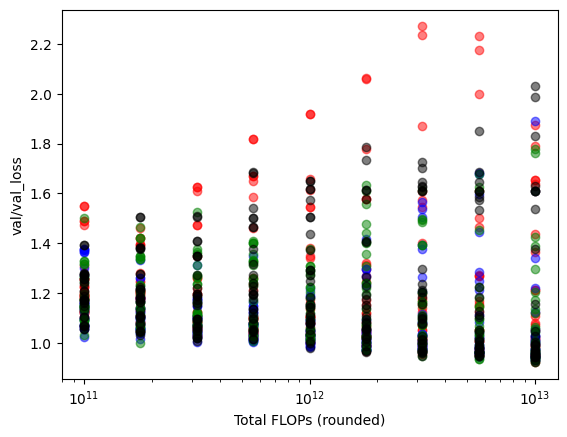

In [153]:
plt.clf()

METRIC = "val/val_loss"

_colors = ["red", "blue", "green", "black", "purple", "cyan", "magenta", "yellow"]

for j, _seed in enumerate(_df_floplist.seed.unique()):
    _df = _df_floplist.loc[_df_floplist.seed == _seed]
    for i in range(len(_df)):
        row = _df.iloc[i]
        plt.scatter(row.total_flops_rounded, row[METRIC], color=_colors[j], alpha=0.5)

    plt.xscale("log")
    plt.xlabel("Total FLOPs (rounded)")
    plt.ylabel(METRIC)

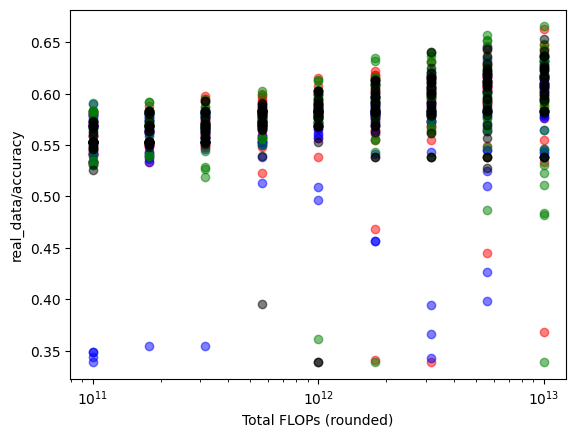

In [154]:
plt.clf()

METRIC = "real_data/accuracy"

_colors = ["red", "blue", "green", "black", "purple", "cyan", "magenta", "yellow"]

for j, _seed in enumerate(_df_floplist.seed.unique()):
    _df = _df_floplist.loc[_df_floplist.seed == _seed]
    for i in range(len(_df)):
        row = _df.iloc[i]
        plt.scatter(row.total_flops_rounded, row[METRIC], color=_colors[j], alpha=0.5)

    plt.xscale("log")
    plt.xlabel("Total FLOPs (rounded)")
    plt.ylabel(METRIC)

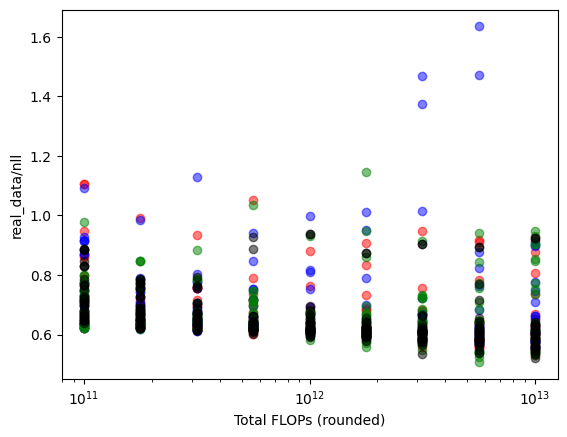

In [155]:
plt.clf()

METRIC = "real_data/nll"

_colors = ["red", "blue", "green", "black", "purple", "cyan", "magenta", "yellow"]

for j, _seed in enumerate(_df_floplist.seed.unique()):
    _df = _df_floplist.loc[_df_floplist.seed == _seed]
    for i in range(len(_df)):
        row = _df.iloc[i]
        plt.scatter(row.total_flops_rounded, row[METRIC], color=_colors[j], alpha=0.5)

    plt.xscale("log")
    plt.xlabel("Total FLOPs (rounded)")
    plt.ylabel(METRIC)

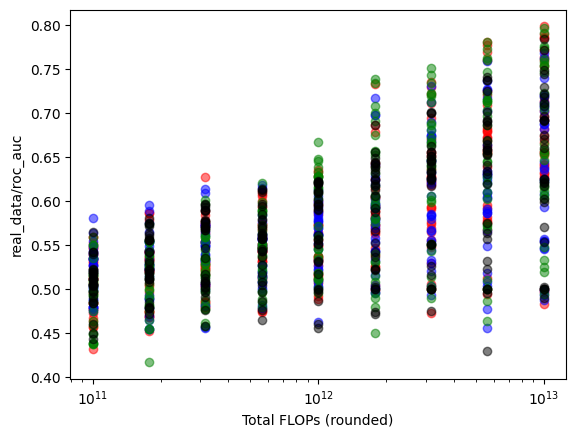

In [156]:
plt.clf()

METRIC = "real_data/roc_auc"

_colors = ["red", "blue", "green", "black", "purple", "cyan", "magenta", "yellow"]

for j, _seed in enumerate(_df_floplist.seed.unique()):
    _df = _df_floplist.loc[_df_floplist.seed == _seed]
    for i in range(len(_df)):
        row = _df.iloc[i]
        plt.scatter(row.total_flops_rounded, row[METRIC], color=_colors[j], alpha=0.5)

    plt.xscale("log")
    plt.xlabel("Total FLOPs (rounded)")
    plt.ylabel(METRIC)

In [ ]:
# pareto per seed
# fit L0, alpha, A
# compare variance across seeds

In [157]:
# working dataframe

# _df_floplist = df  # NOTE: use this if data preprocessing consistent

display(_df_floplist.head())

,config/effective_batch_size,config/lr,config/max_features,config/model_config.embedding_size,config/model_config.num_layers,config/num_datapoints_max,config/weight_decay,parameters,config_path,seed,...,real_data/inference_time,real_data/memory_usage,real_data/balanced_accuracy,real_data/roc_auc,real_data/nll,real_data/accuracy,val/val_loss,val/medium/val_loss,val/small/val_loss,total_flops_rounded
0,32,0.00347,4,16,2,100,0.0000,10602.0,/work/dlclarge2/hogj-scaling_nano_tabpfn/resul...,1826,...,step 148 0.335012 261 0.334930 468 ...,step 148 369.515589 261 369.515589 4...,step 148 0.435010 261 0.437612 468 ...,step 148 0.522680 261 0.521500 468 ...,step 148 0.683696 261 0.662698 468 ...,step 148 0.558930 261 0.562815 468 ...,step 148 1.186853 261 1.211007 468 ...,step 148 1.241395 261 1.272892 468 ...,step 148 1.132310 261 1.149121 468 ...,step 203 1.000000e+11 364 1.778279e+...
1,32,0.00347,4,16,2,400,0.0000,10602.0,/work/dlclarge2/hogj-scaling_nano_tabpfn/resul...,1826,...,step 35 0.338544 63 0.339071 113 ...,step 35 369.515589 63 369.515589 113...,step 35 0.436111 63 0.435938 113 ...,step 35 0.431585 63 0.452437 113 ...,step 35 0.795252 63 0.696930 113 ...,step 35 0.553257 63 0.553123 113 ...,step 35 1.205210 63 1.204930 113 ...,step 35 1.221326 63 1.233696 113 ...,step 35 1.189095 63 1.176164 113 ...,step 49 1.000000e+11 87 1.778279e+11...
2,32,0.00347,8,16,4,200,0.0001,19402.0,/work/dlclarge2/hogj-scaling_nano_tabpfn/resul...,1826,...,step 28 0.570807 47 0.570830 79 ...,step 28 369.633108 47 369.633108 79 ...,step 28 0.432574 47 0.428867 79 ...,step 28 0.506492 47 0.496227 79 ...,step 28 0.761333 47 0.727674 79 ...,step 28 0.549688 47 0.543865 79 ...,step 28 1.180133 47 1.183615 79 ...,step 28 1.202253 47 1.217748 79 ...,step 28 1.158013 47 1.149482 79 ...,step 35 1.000000e+11 62 1.778279e+11...
3,32,0.01000,2,16,1,100,0.0001,6202.0,/work/dlclarge2/hogj-scaling_nano_tabpfn/resul...,1826,...,step 378 0.225194 673 0.227396 1195 ...,step 378 357.957745 673 357.957745 1...,step 378 0.436611 673 0.449633 1195 ...,step 378 0.552414 673 0.578437 1195 ...,step 378 0.633445 673 0.625694 1195 ...,step 378 0.583290 673 0.587586 1195 ...,step 378 1.194206 673 1.085245 1195 ...,step 378 1.247788 673 1.108002 1195 ...,step 378 1.140625 673 1.062488 1195 ...,step 525 1.000000e+11 933 1.778279e+...
4,32,0.01000,2,16,1,200,0.0000,6202.0,/work/dlclarge2/hogj-scaling_nano_tabpfn/resul...,1826,...,step 188 0.219689 333 0.219120 593 ...,step 188 357.957745 333 357.957745 5...,step 188 0.425969 333 0.437041 593 ...,step 188 0.559441 333 0.586064 593 ...,step 188 0.654130 333 0.629424 593 ...,step 188 0.558623 333 0.569849 593 ...,step 188 1.259041 333 1.247642 593 ...,step 188 1.310807 333 1.322435 593 ...,step 188 1.207275 333 1.172849 593 ...,step 260 1.000000e+11 462 1.778279e+...


##### Per SEED


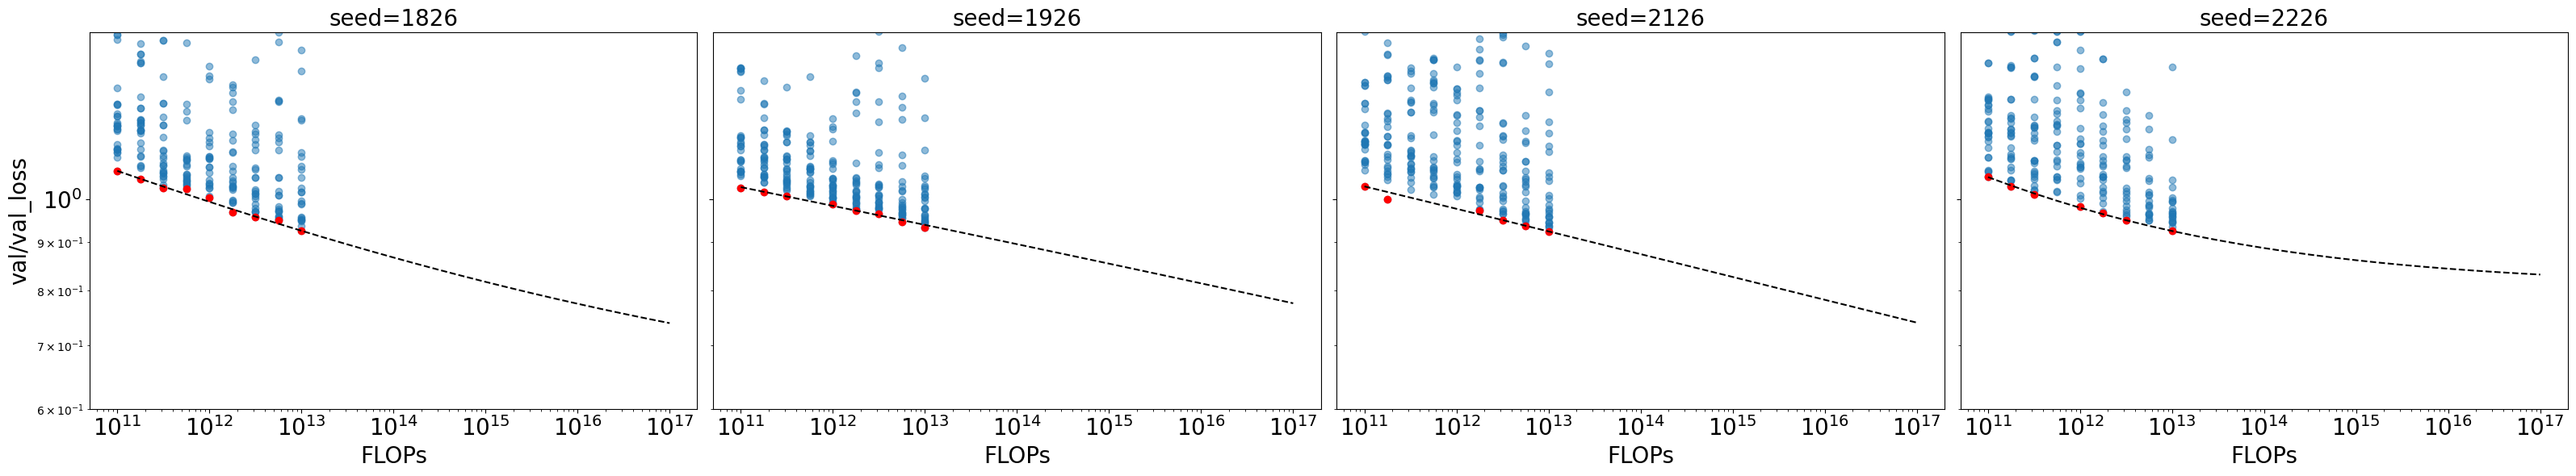

            L0         a     alpha
seed                              
1826  0.570254  2.450958 -0.091261
1926  0.109348  1.375178 -0.033712
2126  0.210948  1.551000 -0.043428
2226  0.807821  3.998338 -0.176174

Summary:
           mean      std.
L0     0.424593  0.323060
a      2.343868  1.199408
alpha -0.086144  0.065078


In [158]:
# FITTING L0 FORM WITH PARETO PER SEED

_METRIC = "val/val_loss"
param_names = {0: "L0", 1: "a", 2: "alpha"}

initial_grid = [
    [0, 0.1, 0.5],
    [0.1, 1, 2, 5, 10, 50, 100],
    [-1, -0.5, 0, 0.5, 1]
]
bounds = [
    (1e-6, 1),
    (0, 100),
    (-5, 5)
]

_SEEDS = list(set(SEEDS) - set([PARENT_SEED]))
n_seeds = len(_SEEDS)
fig, axes = plt.subplots(1, n_seeds, figsize=(8 * n_seeds, 6), sharey=True)
if n_seeds == 1:
    axes = [axes]

all_params = []

for ax, seed in zip(axes, sorted(_SEEDS)):
    # subset for seed
    _df = _df_floplist.loc[_df_floplist.seed == seed]

    # flatten dataframe for seed
    df_flat = _df.explode(["total_flops_rounded", _METRIC]).reset_index(drop=True)

    _pareto = get_pareto_frontier(
        df_flat,
        x_name="total_flops_rounded",
        y_name=_METRIC,
    )

    ax.scatter(df_flat.total_flops_rounded, df_flat[_METRIC], alpha=0.5)
    ax.scatter(_pareto.total_flops_rounded, _pareto[_METRIC], color="red")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"seed={seed}", fontsize=20)
    ax.set_xlabel("FLOPs", fontsize=20)
    ax.tick_params(axis="both", labelsize=20)

    best_params, best_loss = fit_parametric_form(
        func_form=functional_form_L0,
        X_data=_pareto.total_flops_rounded.values,
        y_data=_pareto[_METRIC].values,
        initial_grid=list(product(*initial_grid)),
        bounds=bounds,
        delta=1e-3,
        use_scipy=True,
    )

    ax.plot(
        FLOP_VALUES,
        functional_form_L0(FLOP_VALUES, best_params),
        linestyle="--",
        color="black",
    )

    all_params.append({"seed": seed, **{param_names[i]: v for i, v in enumerate(best_params)}})

params_df = pd.DataFrame(all_params).set_index("seed")

axes[0].set_ylabel(_METRIC, fontsize=20)
axes[0].set_ylim(0.6, 1.5)
plt.tight_layout()
plt.show()

# Summary table
summary = pd.concat([
    params_df.mean().rename("mean"),
    params_df.std().rename("std."),
], axis=1)
print(params_df.to_string())
print("\nSummary:")
print(summary.to_string())


##### All SEEDs


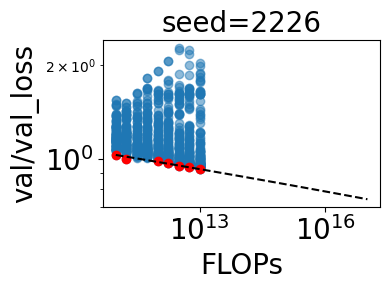

            L0         a     alpha
seed                              
2226  0.007557  1.487783 -0.035849


In [159]:
# FITTING L0 FORM WITH PARETO FOR ALL SEEDS

_METRIC = "val/val_loss"
param_names = {0: "L0", 1: "a", 2: "alpha"}

initial_grid = [
    [0, 0.1, 0.5],
    [0.1, 1, 2, 5, 10, 50, 100],
    [-1, -0.5, 0, 0.5, 1]
]
bounds = [
    (1e-6, 1),
    (0, 100),
    (-5, 5)
]

_SEEDS = list(set(SEEDS) - set([PARENT_SEED]))
n_seeds = len(_SEEDS)
fig, ax = plt.subplots(1, 1, figsize=(4, 3))

all_params = []

_df = _df_floplist.loc[_df_floplist.seed.isin(_SEEDS)]
# flatten dataframe for seed
df_flat = _df.explode(["total_flops_rounded", _METRIC]).reset_index(drop=True)

_pareto = get_pareto_frontier(
    df_flat,
    x_name="total_flops_rounded",
    y_name=_METRIC,
)

ax.scatter(df_flat.total_flops_rounded, df_flat[_METRIC], alpha=0.5)
ax.scatter(_pareto.total_flops_rounded, _pareto[_METRIC], color="red")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title(f"seed={seed}", fontsize=20)
ax.set_xlabel("FLOPs", fontsize=20)
ax.tick_params(axis="both", labelsize=20)

best_params, best_loss = fit_parametric_form(
    func_form=functional_form_L0,
    X_data=_pareto.total_flops_rounded.values,
    y_data=_pareto[_METRIC].values,
    initial_grid=list(product(*initial_grid)),
    bounds=bounds,
    delta=1e-3,
    use_scipy=True,
)

ax.plot(
    FLOP_VALUES,
    functional_form_L0(FLOP_VALUES, best_params),
    linestyle="--",
    color="black",
)

all_params.append({"seed": seed, **{param_names[i]: v for i, v in enumerate(best_params)}})

params_df = pd.DataFrame(all_params).set_index("seed")

ax.set_ylabel(_METRIC, fontsize=20)
# ax.set_ylim(0.6, 1.5)
plt.tight_layout()
plt.show()

# Summary table
summary = pd.concat([
    params_df.mean().rename("mean"),
    params_df.std().rename("std."),
], axis=1)
print(params_df.to_string())
# print("\nSummary:")
# print(summary.to_string())


---

### Looking at config membership to Non-dominated fronts

In [160]:
_retain_cols = _hps + ["parameters", "seed", "total_flops_rounded", _METRIC]

_df = _df_floplist.loc[_df_floplist.seed == _seed]
_pareto = get_pareto_frontier(
    # flattened _df
    _df.explode(["total_flops_rounded", _METRIC]).reset_index(drop=True),
    x_name="total_flops_rounded",
    y_name=_METRIC,
)
_pareto = _pareto[[c for c in _retain_cols if c in _pareto.columns]]

In [162]:
# Generating Pareto/per seed and taking union of all such configs to see how they appear across seeds

_retain_cols = _hps + ["parameters", "seed", "total_flops_rounded", _METRIC]

config_matrix = {}

for _seed in set(SEEDS) - set([PARENT_SEED]):
    _df = _df_floplist.loc[_df_floplist.seed == _seed]
    _pareto = get_pareto_frontier(
        # flattened _df
        _df.explode(["total_flops_rounded", _METRIC]).reset_index(drop=True),
        x_name="total_flops_rounded",
        y_name=_METRIC,
    )
    _pareto = _pareto[[c for c in _retain_cols if c in _pareto.columns]]
    # unique configs in this seed's pareto
    pareto_configs = set(_pareto[_hps].apply(tuple, axis=1))
    config_matrix[_seed] = pareto_configs

# union of all configs as index
all_configs = sorted(set().union(*config_matrix.values()))

# creates a dataframe with unique HP configs as index
df_config = pd.DataFrame(
    {seed: [1 if cfg in configs else 0 for cfg in all_configs]
     for seed, configs in config_matrix.items()},
    index=pd.MultiIndex.from_tuples(all_configs, names=_hps),
)

# column holding how many times the unique HP features in a Pareto across seeds
df_config["membership"] = df_config.sum(axis=1)
df_config.sort_values("membership", ascending=False, inplace=True)
display(df_config)

2226  \
config/effective_batch_size config/lr config/max_features config/model_config.embedding_size config/model_config.num_layers config/num_datapoints_max config/weight_decay         
64.0                        0.070711  2.0                 8.0                                1.0                            100.0                     0.0001                  1   
32.0                        0.010000  4.0                 16.0                               2.0                            200.0                     0.0000                  1   
64.0                        0.010000  8.0                 16.0                               2.0                            100.0                     0.0001                  0   
32.0                        0.010000  2.0                 16.0                               1.0                            100.0                     0.0001                  0   
                                                                                                                            200.0                     0.0000                  1   
                                                                                                                                                      0.0001                  1   
64.0                        0.070711  2.0                 8.0                                1.0                            100.0                     0.0000                  1   
32.0                        0.010000  2.0                 16.0                               2.0                            100.0                     0.0000                  0   
                                                                                                                                                      0.0001                  0   
64.0                        0.003470  4.0                 16.0                               2.0                            200.0                     0.0000                  0   
                            0.010000  4.0                 16.0                               2.0                            200.0                     0.0001                  0   

                                                                                                                                                                           2126  \
config/effective_batch_size config/lr config/max_features config/model_config.embedding_size config/model_config.num_layers config/num_datapoints_max config/weight_decay         
64.0                        0.070711  2.0                 8.0                                1.0                            100.0                     0.0001                  1   
32.0                        0.010000  4.0                 16.0                               2.0                            200.0                     0.0000                  1   
64.0                        0.010000  8.0                 16.0                               2.0                            100.0                     0.0001                  1   
32.0                        0.010000  2.0                 16.0                               1.0                            100.0                     0.0001                  0   
                                                                                                                            200.0                     0.0000                  0   
                                                                                                                                                      0.0001                  0   
64.0                        0.070711  2.0                 8.0                                1.0                            100.0                     0.0000                  0   
32.0                        0.010000  2.0                 16.0                               2.0                            100.0                     0.0000                  0   
                                                     

In [196]:
# Generating Pareto fronts iteratively and assigning front numbers to configs for each seed

_retain_cols = _hps + ["parameters", "seed", "total_flops_rounded", _METRIC]
K = 5  # number of fronts to compute

config_matrix = {}

for _seed in set(SEEDS) - {PARENT_SEED}:
    _df = _df_floplist.loc[_df_floplist.seed == _seed]
    df_flat = _df.explode(["total_flops_rounded", _METRIC]).reset_index(drop=True)

    remaining = df_flat.copy()
    seed_config_fronts = {}  # config_tuple -> front number

    for front in range(1, K + 1):
        if remaining.empty:
            break
        _pareto = get_pareto_frontier(
            remaining,
            x_name="total_flops_rounded",
            y_name=_METRIC,
        )
        _pareto = _pareto[[c for c in _retain_cols if c in _pareto.columns]]

        for cfg in _pareto[_hps].apply(tuple, axis=1):
            if cfg not in seed_config_fronts:  # first front wins
                seed_config_fronts[cfg] = front

        # remove pareto points from remaining
        pareto_idx = _pareto.index
        remaining = remaining.drop(index=pareto_idx, errors="ignore")

    config_matrix[_seed] = seed_config_fronts

# union of all configs as index
all_configs = sorted(set().union(*[set(d.keys()) for d in config_matrix.values()]))

df_config = pd.DataFrame(
    {seed: [d.get(cfg, None) for cfg in all_configs]
     for seed, d in config_matrix.items()},
    index=pd.MultiIndex.from_tuples(all_configs, names=_hps),
)

df_config["min_front"] = df_config.min(axis=1)
df_config["max_front"] = df_config.max(axis=1)
df_config["front_range"] = df_config["max_front"] - df_config["min_front"]
df_config["no_fronts"] = df_config.isna().sum(axis=1)

# df_config.sort_values("front_range", ascending=False, inplace=True)
df_config.sort_values("no_fronts", ascending=True, inplace=True)
display(df_config)


2226  \
config/effective_batch_size config/lr config/max_features config/model_config.embedding_size config/model_config.num_layers config/num_datapoints_max config/weight_decay         
64.0                        0.070711  2.0                 8.0                                1.0                            100.0                     0.0001                1.0   
                            0.010000  8.0                 16.0                               2.0                            200.0                     0.0000                4.0   
32.0                        0.010000  2.0                 16.0                               1.0                            100.0                     0.0001                3.0   
64.0                        0.010000  8.0                 16.0                               2.0                            100.0                     0.0001                2.0   
32.0                        0.010000  2.0                 16.0                               2.0                            100.0                     0.0001                4.0   
                                      4.0                 16.0                               2.0                            100.0                     0.0000                3.0   
                                                                                                                            200.0                     0.0000                1.0   
64.0                        0.070711  2.0                 8.0                                1.0                            100.0                     0.0000                1.0   
32.0                        0.070711  4.0                 8.0                                1.0                            400.0                     0.0000                2.0   
                            0.010000  2.0                 16.0                               1.0                            200.0                     0.0001                1.0   
                                                                                             2.0                            100.0                     0.0000                2.0   
64.0                        0.010000  4.0                 16.0                               4.0                            200.0                     0.0001                5.0   
                                                                                                                                                      0.0000                4.0   
                                                                                             2.0                            200.0                     0.0001                NaN   
                                      2.0                 16.0                               2.0                            100.0                     0.0001                NaN   
32.0                        0.003470  4.0                 16.0                               2.0                            100.0                     0.0000                NaN   
                            0.010000  4.0                 16.0                               2.0                            400.0                     0.0000                NaN   
                                      2.0                 16.0                               1.0                            200.0                     0.0000                1.0   
                            0.003470  8.0                 16.0                               4.0                            200.0                     0.0001                NaN   
64.0                        0.003470  4.0                 16.0                               2.0                            200.0                     0.0000                NaN   
32.0                        0.010000  2.0                 16.0                               4.0                            200.0                     0.0000                3.0   
64.0                        0.010000  2.0             

In [197]:
# CALCULATING SPEARMAN RANK CORRELATION OF FRONT MEMBERSHIP ACROSS ALL SEEDS

seed_cols = list(set(SEEDS) - set([PARENT_SEED]))

result = stats.spearmanr(df_config[seed_cols], nan_policy="omit")

corr_matrix = pd.DataFrame(result.statistic, index=seed_cols, columns=seed_cols)
pval_matrix = pd.DataFrame(result.pvalue, index=seed_cols, columns=seed_cols)
display(corr_matrix)
display(pval_matrix)

,2226,2126,1826,1926
2226,1.000000,0.582961,0.347033,0.151572
2126,0.582961,1.000000,0.351432,0.143599
1826,0.347033,0.351432,1.000000,0.090770
1926,0.151572,0.143599,0.090770,1.000000


,2226,2126,1826,1926
2226,0.000000,0.099454,0.295739,0.604973
2126,0.099454,0.000000,0.289243,0.673591
1826,0.295739,0.289243,0.000000,0.779058
1926,0.604973,0.673591,0.779058,0.000000


In [199]:
# Score each config by its mean front rank across seeds, penalized by inconsistency.
# NaNs (not in any front) are treated as front 2*K — worse than the last observed front.
# Lower score = consistently appears in earlier fronts across seeds.
filled = df_config[seed_cols].fillna(2 * K)
df_config["mean_std_score"] = filled.mean(axis=1) + filled.std(axis=1)

# Fraction of seeds where this config appeared in the top `top_k` fronts.
# Combined with std of front ranks to penalize inconsistency.
# Final score: lower top_front_rate and higher variance both push score up (worse).
top_k = 2
df_config["top_front_score"] = df_config[seed_cols].apply(
    lambda row: (row <= top_k).sum() / len(seed_cols), axis=1
)
df_config["top_front_score"] = -df_config["top_front_score"] + df_config[seed_cols].fillna(2 * K).std(axis=1)


df_config.sort_values(["top_front_score", "mean_std_score", "min_front"], inplace=True)
display(df_config)

2226  \
config/effective_batch_size config/lr config/max_features config/model_config.embedding_size config/model_config.num_layers config/num_datapoints_max config/weight_decay         
64.0                        0.070711  2.0                 8.0                                1.0                            100.0                     0.0001                1.0   
                            0.010000  8.0                 16.0                               2.0                            100.0                     0.0001                2.0   
                            0.070711  2.0                 8.0                                1.0                            100.0                     0.0000                1.0   
32.0                        0.010000  2.0                 16.0                               1.0                            100.0                     0.0001                3.0   
                                      4.0                 16.0                               2.0                            100.0                     0.0000                3.0   
                            0.070711  4.0                 8.0                                1.0                            400.0                     0.0000                2.0   
64.0                        0.010000  8.0                 16.0                               2.0                            200.0                     0.0000                4.0   
32.0                        0.010000  2.0                 16.0                               2.0                            100.0                     0.0001                4.0   
                                      4.0                 16.0                               2.0                            200.0                     0.0000                1.0   
                                                                                                                            400.0                     0.0001                NaN   
                                      2.0                 16.0                               2.0                            100.0                     0.0000                2.0   
                                                                                             4.0                            200.0                     0.0000                3.0   
64.0                        0.010000  2.0                 16.0                               2.0                            100.0                     0.0000                NaN   
                                      4.0                 16.0                               4.0                            200.0                     0.0001                5.0   
32.0                        0.010000  2.0                 16.0                               1.0                            200.0                     0.0001                1.0   
64.0                        0.010000  4.0                 16.0                               4.0                            200.0                     0.0000                4.0   
32.0                        0.003470  4.0                 16.0                               2.0                            100.0                     0.0000                NaN   
64.0                        0.010000  2.0                 16.0                               2.0                            100.0                     0.0001                NaN   
32.0                        0.010000  4.0                 16.0                               2.0                            400.0                     0.0000                NaN   
                            0.003470  8.0                 16.0                               4.0                            200.0                     0.0001                NaN   
64.0                        0.003470  4.0                 16.0                               2.0                            200.0                     0.0000                NaN   
                            0.010000  4.0             